<a href="https://colab.research.google.com/github/CamilaAg-05/curso_Data_Analytics/blob/main/SECOP_ExpedienteA(GRUPO_1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<style>
.jp-RenderedHTMLCommon,
.text_cell_render {
  font-family: medium-content-serif-font, Georgia, Cambria, "Times New Roman", Times, serif;
  font-size: 17px;
  line-height: 1.65;
  color: #1f2328;
}
.jp-RenderedHTMLCommon h1,
.jp-RenderedHTMLCommon h2,
.jp-RenderedHTMLCommon h3,
.text_cell_render h1,
.text_cell_render h2,
.text_cell_render h3 {
  font-family: sohne, "Helvetica Neue", Helvetica, Arial, sans-serif;
  color: #111;
}
.jp-RenderedHTMLCommon h1,
.text_cell_render h1 {
  font-size: 2.6rem;
  letter-spacing: -0.03em;
}
.jp-RenderedHTMLCommon h2,
.text_cell_render h2 {
  margin-top: 1.8em;
}
</style>

# Expediente A. ¿Vale la pena contratar con el Estado?

Data Analytics | Semanas 7–8 | 2026-2

Este notebook acompaña la lectura ¿Qué puede decir realmente un contrato público?

Afirmación que se investigará:

Para un profesional que comienza su vida laboral, la contratación por prestación de servicios con el Estado puede ser una alternativa económicamente atractiva.

Este expediente utiliza un único archivo: `data/secop_recorte.csv`.

Durante la primera semana se construyen tres evidencias y se documentan tres decisiones de preparación. En la segunda semana se incorpora una objeción y se revisa si la conclusión inicial se mantiene.

El objetivo es que cada cifra utilizada en la conclusión pueda localizarse en el notebook y que el alcance de la afirmación corresponda a lo que realmente muestran los datos.


## Preparar los datos

Ubique el notebook junto a la carpeta `data`.

```text
Expediente_A.ipynb
data/
└── secop_recorte.csv
```

No es necesario descargar datos, seleccionar un equipo ni modificar filtros.


In [1]:
from pathlib import Path
from statistics import NormalDist
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

DATA_FILE = Path("data") / "secop_recorte.csv"

if not DATA_FILE.exists():
    raise FileNotFoundError("No se encontró data/secop_recorte.csv.")

df_raw = pd.read_csv(DATA_FILE, dtype=str)

print("Archivo:", DATA_FILE.name)
print("Filas:", f"{len(df_raw):,}")
print("Columnas:", df_raw.shape[1])


Archivo: secop_recorte.csv
Filas: 39,928
Columnas: 85


## Comprender el archivo antes de analizarlo

Cada fila de `secop_recorte.csv` representa un contrato incluido en el conjunto asignado al equipo. El archivo no corresponde a todo SECOP II, sino a una parte previamente seleccionada para la actividad.

La columna `ciudad`, cuando está disponible, identifica la ciudad de registro de la entidad que publica el contrato. No debe interpretarse automáticamente como el lugar físico donde se ejecutó el servicio, la obra o el suministro.

Las siguientes conversiones permiten trabajar con valores y fechas sin eliminar registros.


In [2]:
df = df_raw.copy()

for column in ["valor_del_contrato", "dias_adicionados"]:
    if column in df.columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

for column in [
    "fecha_de_firma",
    "fecha_de_inicio_del_contrato",
    "fecha_de_fin_del_contrato",
]:
    if column in df.columns:
        df[column] = pd.to_datetime(df[column], errors="coerce")

if {
    "fecha_de_inicio_del_contrato",
    "fecha_de_fin_del_contrato",
}.issubset(df.columns):
    df["duracion_dias"] = (
        df["fecha_de_fin_del_contrato"]
        - df["fecha_de_inicio_del_contrato"]
    ).dt.days

if {"valor_del_contrato", "duracion_dias"}.issubset(df.columns):
    months = df["duracion_dias"] / 30.44
    df["valor_mensual_equivalente"] = (
        df["valor_del_contrato"] / months.where(months > 0)
    )

sample_columns = [
    c for c in [
        "id_contrato",
        "nombre_entidad",
        "ciudad",
        "proveedor_adjudicado",
        "tipo_de_contrato",
        "modalidad_de_contratacion",
        "valor_del_contrato",
        "fecha_de_firma",
    ]
    if c in df.columns
]

df[sample_columns].head()


,id_contrato,nombre_entidad,ciudad,proveedor_adjudicado,tipo_de_contrato,modalidad_de_contratacion,valor_del_contrato,fecha_de_firma
0,CO1.PCCNTR.7325911,MINISTERIO DEL INTERIOR,Bogotá,Carmen Elena Ordoñez Lasso,Prestación de servicios,Contratación directa,104470000.0,2025-01-27
1,CO1.PCCNTR.6446468,DEFENSORÍA DEL PUEBLO,Bogotá,JULIETA BAUTISTA DUARTE,Prestación de servicios,Contratación directa,32838000.0,2024-06-24
2,CO1.PCCNTR.8501557,SECRETARIA DE EDUCACION DEL DISTRITO,No Definido,Indira Liliana Ortiz Salas,Prestación de servicios,Contratación directa,100866667.0,2025-10-29
3,CO1.PCCNTR.6005411,IDARTES,Bogotá,jhoana maricela urquijo ramirez,Prestación de servicios,Contratación directa,9572200.0,2024-02-27
4,CO1.PCCNTR.7683540,ALCALDÍA LOCAL DE SUBA,Bogotá,CRISTINA RAMIREZ,Prestación de servicios,Contratación directa,46128000.0,2025-03-21


### Antes de seguir

1. **¿Qué representa una fila?**

Cada fila representa un contrato individual registrado en SECOP II (específicamente de Prestación de Servicios en Bogotá D.C.).
39,928 filas son 39,928 contratos no necesariamente 39,928 personas, ya que puede darse el caso de que un mismo contratista puede aparecer en varias filas si firmó más de un contrato en ese periodo

2. **¿Qué información permite identificar a la entidad y al proveedor?**

La identificación de la entidad contratante se hace principalmente a través de nombre_entidad, que trae el nombre de la entidad del Estado que publicó y firmó el contrato.Del lado del proveedor, la columna visible en la muestra es proveedor_adjudicado, que trae el nombre de la persona o entidad a la que le dieron el contrato.


3. **¿Qué variable monetaria aparece en el archivo?**

La variable monetaria central del expediente es valor_del_contrato, que registra el valor total pactado del contrato en pesos colombianos, esta es una variable de valor total del contrato, no de ingreso mensual ni de salario

4. ¿Qué variable o columna necesita comprender mejor antes de utilizarla?




## Primera semana: describir el conjunto asignado

La primera revisión se concentra en `valor_del_contrato`. Se estudiará una variable por separado antes de introducir comparaciones entre grupos.

La media, la mediana y los percentiles no responden exactamente la misma pregunta. Si la distribución contiene unos pocos contratos de valor muy alto, la media puede alejarse considerablemente de la mediana.


In [3]:
if "valor_del_contrato" not in df.columns:
    raise KeyError("El archivo no contiene la columna valor_del_contrato.")

contract_value = df["valor_del_contrato"].dropna()

value_summary = pd.Series({
    "contratos con valor registrado": len(contract_value),
    "media": contract_value.mean(),
    "mediana": contract_value.median(),
    "percentil 25": contract_value.quantile(0.25),
    "percentil 75": contract_value.quantile(0.75),
    "percentil 90": contract_value.quantile(0.90),
    "mínimo": contract_value.min(),
    "máximo": contract_value.max(),
    "contratos con valor 0": int((contract_value == 0).sum()),
})

value_summary.to_frame("resultado")


,resultado
contratos con valor registrado,3.992700e+04
media,7.596195e+07
mediana,3.347696e+07
percentil 25,1.831667e+07
percentil 75,5.477348e+07
percentil 90,8.880000e+07
mínimo,0.000000e+00
máximo,1.612908e+11
contratos con valor 0,7.200000e+01


# Análisis
Contratos con valor registrado: 39,927

Media: 75,961,950

Mediana: 33,476,960

Percentil 25: 18,316,670

Percentil 75: 54,773,480

Percentil 90: 88,800,000

Mínimo: 0

Máximo: 161,290,800,000

Contratos con valor 0: 72

En nuestro recorte, la media (75,96M COP) casi duplica a la mediana (33,48M COP), y esa diferencia tan grande puede significar que algo no está distribuido de forma pareja. La media es el promedio normal: se suman todos los valores y se dividen entre el número de contratos, pero es muy sensible a valores extremos ya que si un solo contrato vale muchísimo más que el resto, ese contrato hace que el promedio suba aunque no sea representativo de nada. La mediana, en cambio, es el valor que queda justo en la mitad si ordenamos todos los contratos de menor a mayor es decir no importa qué tan grande sea el contrato más caro.

El percentil 90 dice que el 90% de los contratos vale 88,8M COP o menos, pero el contrato más caro del recorte llega a 161.290.800.000 COP, que es mucho más grande que el resto. Lo que hace que un solo contrato así sea suficiente para empujar la media hacia arriba y alejarla de lo que realmente es un contrato típico de nuestro caso.

Además de esto, notamos 72 contratos con valor 0 COP (0,18% del total).Tambien el contrato de 161.290.800.000 COP, que es tan extremo frente al resto de contratos.

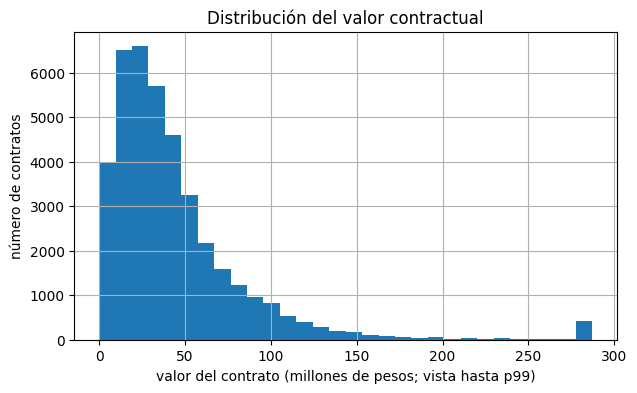

In [4]:
upper_view = contract_value.quantile(0.99)

plt.figure(figsize=(7, 4))
(contract_value.clip(upper=upper_view) / 1_000_000).hist(bins=30)
plt.xlabel("valor del contrato (millones de pesos; vista hasta p99)")
plt.ylabel("número de contratos")
plt.title("Distribución del valor contractual")
plt.show()


# Análisis

La grafica confirma visualmente el sesgo que ya vimos en la tabla anterior donde la mayoría de los contratos se concentra entre 0 y 50 millones de pesos, coherente con la mediana de 33,48M COP.Entre más sube el precio del contrato, menos casos hay.

### Deténgase y revise

1. ¿La media y la mediana son semejantes o muy diferentes?

La media (75,96M COP) es casi el doble de la mediana (33,48M COP). Una diferencia tan grande significa que los montos de los contratos no están repartidos de forma pareja.

2. ¿Cuál de las dos describe mejor un contrato típico dentro de estos datos?

En este caso, la mediana refleja mucho mejor cómo es un contrato típico en este conjunto de datos., ya que no se altera por valores extremos y muestra dónde está la mayoría.La media, por el contrario, se incrementa considerablemente debido a unos pocos contratos de gran magnitud que distorsionan la tendencia del resto, por ejemplo el contrato de 161.290.800.000 COP


3. ¿Qué muestra el histograma sobre la forma de la distribución?

La gran mayoría de los contratos se concentra en el rango de 0 a 50 millones de pesos, y a partir de ahí la cantidad de casos disminuye rápidamente a medida que el valor aumenta.

4. ¿Por qué limitar la escala visual al percentil 99 no equivale a eliminar esos contratos del análisis?

Eso solo cambia cómo se ve la gráfica, no los datos reales. La media, la mediana y los percentiles ya estaban calculados antes de hacer ese ajuste, así que esos contratos extremos siguen contando en los resultados, es decir que en la grafica solo se está haciendo un acercamiento a la zona donde está la gran mayoría


## Revisar la calidad antes de preparar los datos

Un faltante, un valor en cero, una repetición o un valor extremo no se elimina automáticamente. Primero debe establecerse si afecta la pregunta que se quiere responder.

La siguiente revisión muestra aspectos que pueden modificar las conclusiones.


In [5]:
quality_columns = [
    c for c in [
        "id_contrato",
        "nombre_entidad",
        "ciudad",
        "proveedor_adjudicado",
        "documento_proveedor",
        "valor_del_contrato",
        "fecha_de_inicio_del_contrato",
        "fecha_de_fin_del_contrato",
        "duracion_dias",
    ]
    if c in df.columns
]

quality = pd.DataFrame({
    "faltantes": df[quality_columns].isna().sum(),
    "porcentaje_faltante": (df[quality_columns].isna().mean() * 100).round(1),
    "valores_unicos": df[quality_columns].nunique(dropna=True),
})

display(quality)

if "id_contrato" in df.columns:
    print(
        "IDs de contrato repetidos:",
        int(df["id_contrato"].duplicated(keep=False).sum())
    )

q1, q3 = df["valor_del_contrato"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_iqr = q3 + 1.5 * iqr

print("Contratos con valor 0:", int((df["valor_del_contrato"] == 0).sum()))
print(
    "Posibles valores extremos según 1.5 × IQR:",
    int((df["valor_del_contrato"] > upper_iqr).sum())
)

if "duracion_dias" in df.columns:
    invalid_duration = (
        df["duracion_dias"].isna()
        | (df["duracion_dias"] <= 0)
    ).sum()
    print("Duraciones faltantes o no positivas:", int(invalid_duration))


,faltantes,porcentaje_faltante,valores_unicos
id_contrato,0,0.0,39928
nombre_entidad,0,0.0,333
ciudad,0,0.0,3
proveedor_adjudicado,2,0.0,36810
documento_proveedor,1,0.0,36887
valor_del_contrato,1,0.0,22610
fecha_de_inicio_del_contrato,84,0.2,708
fecha_de_fin_del_contrato,1,0.0,1049
duracion_dias,84,0.2,616


IDs de contrato repetidos: 0
Contratos con valor 0: 72
Posibles valores extremos según 1.5 × IQR: 2242
Duraciones faltantes o no positivas: 174


### Comprobar si una decisión cambia el resultado

Antes de decidir qué hacer con los valores en cero o con los contratos más altos, conviene observar cuánto cambia una estadística sencilla.

La siguiente comparación no prescribe una limpieza. Su función es mostrar si la mediana resulta sensible a tres formas distintas de preparar el valor contractual.


In [6]:
medians = {}

all_values = df["valor_del_contrato"].dropna()
if len(all_values):
    medians["sin retirar ceros"] = all_values.median()

positive_values = df.loc[
    df["valor_del_contrato"] > 0,
    "valor_del_contrato"
].dropna()

if len(positive_values):
    medians["solo valores positivos"] = positive_values.median()

if len(positive_values):
    p99 = positive_values.quantile(0.99)
    below_p99 = positive_values[positive_values <= p99]
    medians["positivos, sin el 1 % superior"] = below_p99.median()

pd.Series(medians, name="mediana_valor")


,mediana_valor
sin retirar ceros,33476958.0
solo valores positivos,33550000.0
"positivos, sin el 1 % superior",33056000.0


### Tres decisiones de preparación

Documente tres decisiones que realmente se desprendan de sus datos. Para cada una, responda:

1. ¿Qué situación encontró?
2. ¿Qué tratamiento decidió aplicar?
3. ¿Qué salida del notebook respalda la decisión?
4. ¿Qué podría cambiar en la conclusión si la decisión fuera equivocada?

No es necesario que todos los equipos adopten las mismas decisiones.


## Expediente A: valor, duración y valor mensual equivalente

El valor total de un contrato no puede compararse directamente con un ingreso mensual. Para aproximar una comparación homogénea se utiliza el valor mensual equivalente estimado, calculado como valor contractual dividido por la duración aproximada en meses.

Esta variable sirve para comparar contratos dentro del ejercicio. No equivale automáticamente a salario ni a honorario mensual.


In [7]:
required = [
    "valor_del_contrato",
    "duracion_dias",
    "valor_mensual_equivalente",
]

missing = [c for c in required if c not in df.columns]

if missing:
    raise KeyError("No están disponibles: " + ", ".join(missing))

case_data = df[
    (df["valor_del_contrato"] > 0)
    & (df["duracion_dias"] > 0)
].copy()

case_data[required].describe(
    percentiles=[0.25, 0.5, 0.75, 0.90]
).T


,count,mean,std,min,25%,50%,75%,90%,max
valor_del_contrato,39731.0,7.433752e+07,1.219203e+09,0.100000,1.849022e+07,3.360000e+07,5.495128e+07,8.883750e+07,1.612908e+11
duracion_dias,39731.0,2.154059e+02,3.500612e+02,1.000000,1.210000e+02,2.050000e+02,3.090000e+02,3.480000e+02,6.592300e+04
valor_mensual_equivalente,39731.0,1.252435e+07,2.706362e+08,0.005051,3.553445e+06,5.335733e+06,7.768701e+06,1.046204e+07,4.206468e+10


In [8]:
# TABLA REDONDEADA

tabla_redondeado = case_data[required].describe(
    percentiles=[0.25, 0.5, 0.75, 0.90]
).T.round(0).astype(int)

tabla_redondeado



,count,mean,std,min,25%,50%,75%,90%,max
valor_del_contrato,39731,74337517,1219202765,0,18490216,33600000,54951280,88837500,161290792640
duracion_dias,39731,215,350,1,121,205,309,348,65923
valor_mensual_equivalente,39731,12524346,270636152,0,3553445,5335733,7768701,10462036,42064681130


### Interpretar el resultado

1. **¿Qué valor mensual equivalente describe mejor un contrato típico?**

La mediana (5,34M COP/mes), no la media (12,52M COP/mes).Otra vez hay valores extremos llevando el promedio hacia arriba, ya que se ve que el máximo llega a $42 mil millones al mes, algo que no es un caso normal.

2. **¿Qué diferencia encuentra entre analizar el valor total y el valor mensual equivalente?**

El valor total no dice nada sobre qué tan rápido o lento se recibe ese dinero: un contrato de $100M en 2 meses no es lo mismo que uno de $100M en 20 meses, aunque el valor total sea igual. El valor mensual equivalente sí permite comparar contratos de distinta duración en las mismas unidades.

3. **¿Qué contratos quedarían fuera de este cálculo y por qué?**

Los que no tienen `valor_del_contrato` o `duracion_dias` válidos (mayores a cero) en nuestro caso, los 174 contratos con duración faltante o no positiva y los que tengan valor 0 o nulo.


4. **¿Qué conclusión sería incorrecta si se interpretara esta variable como salario?**

La variable `valor_mensual_equivalente` es solo una división entre ($\text{valor total} \div \text{meses}$) , no un dato real de cuánto le pagaron a alguien cada mes, y teniendo en cuenta estas razones:

* **No refleja la forma real de pago:** Por ejemplo que un contrato sea de 10 millones COP por 10 meses no significa necesariamente que se de 1 millón COP cada mes.Por ejemplo, se pueden hacer en un único pago inicial.

* **Es el monto total, no el dinero que le queda libre:** A diferencia de un empleo formal donde el empleador asume parte de la seguridad social, en un contrato de prestación de servicios (OPS) el contratista debe pagar de su propio sueldo sus aportes a salud, pensión y ARL. Por ello, el número calculado es el valor bruto del contrato, no lo que realmente le queda disponible a la persona.


## Tablero de evidencia de la primera semana

Seleccione tres hallazgos. Para cada uno registre el hallazgo, la cifra o tabla que lo respalda, una interpretación posible y una duda pendiente.

Una limitación debe aparecer de manera explícita: SECOP permite caracterizar contratos, pero estos datos no permiten establecer quiénes los obtuvieron ni identificar si una persona es recién egresada.


## Segunda semana: poner a prueba la conclusión

Objeción de trabajo: un contrato de valor alto puede parecer atractivo simplemente porque dura más tiempo.

Antes de ejecutar la siguiente comparación, responda:

1. ¿Qué parte de la conclusión inicial pone en duda esta objeción?
2. ¿Qué relación debería observarse entre valor total y duración?
3. ¿Qué aportaría comparar contratos de distinta duración mediante el valor mensual equivalente?


In [ ]:
contrast = df[
    ["valor_del_contrato", "duracion_dias", "valor_mensual_equivalente"]
].dropna()

contrast = contrast[
    (contrast["valor_del_contrato"] > 0)
    & (contrast["duracion_dias"] > 0)
]

rho = contrast["valor_del_contrato"].corr(
    contrast["duracion_dias"],
    method="spearman",
)

print(
    "Correlación de Spearman entre valor total y duración:",
    round(rho, 3)
)

contrast["grupo_duracion"] = pd.qcut(
    contrast["duracion_dias"],
    q=4,
    duplicates="drop",
)

contrast.groupby(
    "grupo_duracion",
    observed=True
)["valor_mensual_equivalente"].agg(["count", "median"])


### Deténgase y revise

1. ¿El hallazgo de la primera semana se mantiene, se debilita o cambia?
2. ¿Los contratos más largos continúan pareciendo más atractivos cuando se usa el valor mensual equivalente?
3. ¿Qué nueva evidencia produjo la comparación?
4. ¿Qué sigue sin poder afirmarse sobre las personas que obtuvieron esos contratos?


## Asociación no significa causalidad

Cuando dos variables cambian conjuntamente, la relación puede tener varias explicaciones. Una tercera variable puede influir sobre ambas y alterar la interpretación; en estadística se habla de una variable de confusión.

Para este expediente, responda:

1. ¿Qué variable podría estar influyendo en la relación observada?
2. ¿Por qué podría modificar la interpretación?
3. ¿Qué información adicional sería necesaria para comprobarlo?


## Pensar un experimento antes de hablar de causalidad

El análisis de SECOP es observacional: trabaja con contratos que ya ocurrieron. No es un experimento A/B.

Describa una comparación ideal:

1. ¿Cuáles serían los grupos A y B?
2. ¿Qué resultado mediría?
3. ¿Sería viable asignar los grupos al azar?
4. ¿Qué diseño observacional o cuasi-experimental utilizaría si la aleatorización no fuera posible?


### Una aproximación al concepto de potencia

La potencia estadística responde una pregunta práctica: si realmente existe una diferencia de interés entre dos grupos, ¿el tamaño de muestra permite detectarla con una probabilidad razonable?

El siguiente cálculo utiliza una aproximación normal para dos grupos de igual tamaño. El propósito es observar la relación entre tamaño de efecto y tamaño de muestra.


In [ ]:
alpha = 0.05
target_power = 0.80
effect_size = 0.50

normal = NormalDist()
z_alpha = normal.inv_cdf(1 - alpha / 2)
z_power = normal.inv_cdf(target_power)

n_per_group = math.ceil(
    2 * ((z_alpha + z_power) / effect_size) ** 2
)

pd.Series({
    "alpha": alpha,
    "potencia_objetivo": target_power,
    "tamaño_de_efecto_estandarizado": effect_size,
    "n_aproximado_por_grupo": n_per_group,
})


### Antes de terminar

1. Si la diferencia de interés fuera más pequeña, ¿esperaría necesitar más o menos observaciones?
2. ¿Por qué disponer de muchas filas no corrige por sí solo un sesgo o una variable de confusión?
3. ¿Qué limitación de este expediente considera más importante después de completar la segunda semana?


## Actividad entregable

El entregable se construye a partir de la ejecución y el análisis de este notebook.

### Tablero de evidencia

Presente tres tarjetas. Cada una debe contener un hallazgo, la evidencia que lo sustenta, una interpretación posible y una duda pendiente. Las cifras deben poder localizarse en las salidas del notebook.

### Decisiones de preparación

Documente tres decisiones tomadas sobre la preparación de los datos. Para cada una indique el problema encontrado, el tratamiento aplicado, la evidencia que respalda la decisión y qué podría cambiar si esa decisión fuera incorrecta.

### Respuesta a la objeción y veredicto

Explique qué cambió después de incorporar la comparación de la segunda semana. El veredicto final debe ser uno de los siguientes:

- respaldada;
- parcialmente respaldada;
- no respaldada.

La conclusión debe incluir la principal limitación del análisis y una breve recomendación.

### Evidencia causal más fuerte

Explique qué diseño permitiría obtener evidencia causal más fuerte. Si un experimento aleatorizado no es viable, proponga una alternativa observacional o cuasi-experimental y justifique qué variable adicional sería necesario controlar.

### Declaración de uso de herramientas de inteligencia artificial

Indique la herramienta empleada, la actividad en la que se utilizó, el resultado que fue verificado y la forma de verificación, y una decisión del equipo que no se delegó a la herramienta.

El notebook entregado debe ejecutarse de principio a fin y reproducir las cifras utilizadas en el tablero y en el veredicto.
